In [1]:
print("Hello, World!")

Hello, World!


## Task 1: Environment Setup

In [1]:
import pandas
import numpy
import matplotlib
import scipy
import networkx
import plotly

print(pandas.__version__)
print(numpy.__version__)
print(matplotlib.__version__)
print(scipy.__version__)
print(networkx.__version__)
print(plotly.__version__)

3.0.6
2.4.6
3.11.2
1.17.1
3.6.1
6.9.0


## Task 2: Collect and Clean OpenAlex Data


### Task 2.1: Data Acquisition

In [2]:
import requests

In [5]:
url = "https://api.openalex.org/institutions"
params = {
    "search": "Florida State University"
}

response = requests.get(url, params=params)
response.raise_for_status()

data = response.json()

for institution in data["results"]:
    print(institution["display_name"], institution["id"])

Florida State University https://openalex.org/I103163165
Florida A&M University - Florida State University College of Engineering https://openalex.org/I1323276237
University of Florida https://openalex.org/I33213144
Florida State University-Panama https://openalex.org/I115600460
State University System of Florida https://openalex.org/I2801649442
FSU Coastal and Marine Laboratory https://openalex.org/I4402554067


In [11]:
import json
import time
from tqdm.auto import tqdm

fsu_id = "I103163165"

url = "https://api.openalex.org/works"

params = {
    "filter": f"institutions.id:{fsu_id},publication_year:2021-2026",    "per-page": 100,
    "cursor": "*",
    "select": "id,doi,display_name,publication_year,publication_date,type,cited_by_count,authorships,primary_location,open_access,concepts"
}

In [12]:
count = 0

with open("fsu_works_2021_2026.jsonl", "w", encoding="utf-8") as file:
    with tqdm(desc="Downloading FSU works", unit="Works") as progress:
        while(params["cursor"]):
            response = requests.get(url, params=params, timeout=60)
            response.raise_for_status()
            data = response.json()

            works = data["results"]

            if not works:
                break

            for work in works:
                file.write(json.dumps(work) + "\n")

            count += len(works)
            progress.update(len(works))

            params["cursor"] = data["meta"].get("next_cursor")
            time.sleep(0.1)

print("Total works downloaded:", count)

Total works downloaded: 27733


### Task 2.2: Cleaning and Flattening

In [1]:
import json
works = []

with open("fsu_works_2021_2026.jsonl", "r", encoding = "utf-8") as file:
    for line in file:
        works.append(json.loads(line))

print("Total records loaded:", len(works))

Total records loaded: 27733


In [2]:
def flatten_work(work):
    location = work.get("primary_location") or {}
    source = location.get("source") or {}
    open_access = work.get("open_access") or {}

    authorships = work.get("authorships") or []
    authors = [
        (a.get("author") or {}).get("display_name", "")
        for a in authorships
    ]

    concepts = work.get("concepts") or []
    fields = [
        c.get("display_name", "")
        for c in concepts
    ]

    return{
        "openalex_id": work.get("id"),
        "doi": work.get("doi"),
        "title": work.get("display_name"),
        "publication_year": work.get("publication_year"),
        "publication_date": work.get("publication_date"),
        "type": work.get("type"),
        "cited_by_count": work.get("cited_by_count"),
        "venue": source.get("display_name"),
        "venue_id": source.get("id"),
        "is_oa": open_access.get("is_oa"),
        "oa_status": open_access.get("oa_status"),
        "authors": "; ".join(authors),
        "n_authors": len(authors),
        "primary_field": fields[0] if fields else None,
        "fields_all": "; ".join(fields)        
    }

### Task 2.3: Create and Save the DataFrame

In [20]:
import pandas as pd

flattened = [flatten_work(work) for work in works]

df = pd.DataFrame(flattened)

df.head()


,openalex_id,doi,title,publication_year,publication_date,type,cited_by_count,venue,venue_id,is_oa,oa_status,authors,n_authors,primary_field,fields_all
0,https://openalex.org/W2963002078,https://doi.org/10.1093/ptep/ptac097,Review of Particle Physics,2022,2022-08-01,article,6045,Progress of Theoretical and Experimental Physics,https://openalex.org/S4210202364,True,gold,Particle Data Group; Ronald Workman; Volker Bu...,100,Physics,Physics; Particle physics; Higgs boson; Supers...
1,https://openalex.org/W4401211033,https://doi.org/10.1103/physrevd.110.030001,Review of Particle Physics,2024,2024-08-01,article,3585,Physical review. D/Physical review. D.,https://openalex.org/S4210238307,True,hybrid,Sergio Navas; C. Amsler; Th. Gutsche; C. Hanha...,100,Particle physics,Particle physics; Physics; Higgs boson; Supers...
2,https://openalex.org/W3108936441,https://doi.org/10.1080/15548627.2020.1797280,Guidelines for the use and interpretation of a...,2021,2021-01-02,article,2742,Autophagy,https://openalex.org/S102544370,True,bronze,Daniel J. Klionsky; Amal Kamal Abdel‐Aziz; Sar...,100,Autophagy,Autophagy; Biology; Interpretation (philosophy...
3,https://openalex.org/W4387440676,https://doi.org/10.1021/acs.jcim.3c01153,AmberTools,2023,2023-10-08,article,2166,Journal of Chemical Information and Modeling,https://openalex.org/S167262187,True,hybrid,David Andrew Case; Hasan Metin Aktulga; Kellon...,47,Computer science,Computer science; Set (abstract data type); Op...
4,https://openalex.org/W3193988690,https://doi.org/10.1063/5.0055522,Software for the frontiers of quantum chemistr...,2021,2021-08-23,article,1434,The Journal of Chemical Physics,https://openalex.org/S77047749,True,bronze,Evgeny Epifanovsky; Andrew T. B. Gilbert; Xint...,100,Software,Software; Quantum chemistry; Software package;...


In [21]:
df.to_csv("fsu_works_2021_2026.csv", index=False)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 27733
Columns: 15


### Task 2: Sanity Check


In [23]:
print("Original records:", len(works))
print("CSV records:", len(df))
print("Columns:", df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum())

Original records: 27733
CSV records: 27733
Columns: ['openalex_id', 'doi', 'title', 'publication_year', 'publication_date', 'type', 'cited_by_count', 'venue', 'venue_id', 'is_oa', 'oa_status', 'authors', 'n_authors', 'primary_field', 'fields_all']

Missing values:
openalex_id            0
doi                  236
title                 11
publication_year       0
publication_date       0
type                   0
cited_by_count         0
venue               2239
venue_id            2239
is_oa                  0
oa_status              0
authors                0
n_authors              0
primary_field       1136
fields_all             0
dtype: int64


In [30]:
check_params = {
    "filter": f"institutions.id:{fsu_id},publication_year:2021-2026",
    "group_by": "publication_year",
    "per-page": 100
}

response = requests.get(
    "https://api.openalex.org/works",
    params=check_params,
    timeout=60
)
response.raise_for_status()

groups = response.json()["group_by"]

api_counts = {
    int(group["key"]): group["count"]
    for group in groups
}

local_counts = df["publication_year"].value_counts().sort_index()
print("OpenAlex counts:", api_counts)
print("\nLocal CSV counts:")
print(local_counts)

OpenAlex counts: {2026: 5336, 2025: 4998, 2024: 4595, 2023: 4381, 2021: 4247, 2022: 4176}

Local CSV counts:
publication_year
2021    4247
2022    4176
2023    4381
2024    4595
2025    4998
2026    5336
Name: count, dtype: int64


In [31]:
comparison = pd.DataFrame({
    "OpenAlex": pd.Series(api_counts),
    "Local CSV": local_counts
}).fillna(0).astype(int)

comparison["Difference"] = (
    comparison["OpenAlex"] - comparison["Local CSV"]
)

print(comparison)

print("\nTotal local records:", len(df))
print("Total OpenAlex records:", sum(api_counts.values()))

      OpenAlex  Local CSV  Difference
2021      4247       4247           0
2022      4176       4176           0
2023      4381       4381           0
2024      4595       4595           0
2025      4998       4998           0
2026      5336       5336           0

Total local records: 27733
Total OpenAlex records: 27733


## Task 3: Descriptive Statistics

In [34]:
import pandas as pd

df = pd.read_csv("fsu_works_2021_2026.csv")

print("Rows:", len(df))
print("Columns:", len(df.columns))

Rows: 27733
Columns: 15


### Task 3.1: Works by Publication Year

In [35]:
works_by_year = df["publication_year"].value_counts().sort_index()

print(works_by_year)

publication_year
2021    4247
2022    4176
2023    4381
2024    4595
2025    4998
2026    5336
Name: count, dtype: int64


FSU's publication counts generally icnreased from 2021 to 2026, with 2026 being the largest despite the year not even being over yet

### Task 3.2: Top 20 Publication Venues

In [36]:
top_venues = df["venue"].value_counts().head(20)

print(top_venues)

venue
DOE Pacific Northwest National Laboratory (PNNL) Repository    986
arXiv (Cornell University)                                     881
SSRN Electronic Journal                                        782
Zenodo (CERN European Organization for Nuclear Research)       530
bioRxiv (Cold Spring Harbor Laboratory)                        406
Cambridge University Press eBooks                              357
Springer eBooks                                                302
Journal of High Energy Physics                                 210
Research Square                                                197
Innovation in Aging                                            174
Physical review. B./Physical review. B                         174
Cureus                                                         161
Nature Communications                                          142
Physical Review Letters                                        140
Physical Review C                                       

The venue ranking excludes publications with missing venue info. 2239 records didnt have a recorded publication venue


The most common venue includes the PNNL repository, followed by arXiv and SSRN electronic journay. Many are repos and preprint platforms instead of just journals. 

### Task 3.3: Citation Statistics

In [37]:
citation_stats = df["cited_by_count"].describe()

print(citation_stats)

count    27733.000000
mean         9.126672
std         57.844898
min          0.000000
25%          0.000000
50%          1.000000
75%          7.000000
max       6045.000000
Name: cited_by_count, dtype: float64


With a mean of 9.13 citations but a median of only 1 citation, there is a small amount of highly cited papers, with most publicatings receiving few citations

### Task 3.4: Top 10 Research Fields

In [38]:
fields_df = df.dropna(subset=["primary_field"])

removed = len(df) - len(fields_df)

print("Records removed:", removed)

field_counts = fields_df["primary_field"].value_counts()

top_fields = field_counts.head(10)

field_percentages = (top_fields / len(fields_df)) * 100

field_summary = pd.DataFrame({
    "Number of Works": top_fields,
    "Percentage (%)": field_percentages
})

print(field_summary)

Records removed: 1136
                       Number of Works  Percentage (%)
primary_field                                         
Medicine                          1549        5.823965
Computer science                   919        3.455277
Physics                            918        3.451517
Psychology                         914        3.436478
Biology                            334        1.255781
Chemistry                          309        1.161785
Materials science                  240        0.902357
Mathematics                        201        0.755724
Business                           175        0.657969
Environmental science              156        0.586532


With a wide range of fields, FSUs research spans multiple disciplines, with medicine being the largest, followed behind a similarly sized computer science, physics, and psychology, with environmental science all the way in the bottom

## Task 4: Static Charts in Matplotlib

In [39]:
import matplotlib.pyplot as plt

### Task 4.1: Distribution of Publications Across Fields

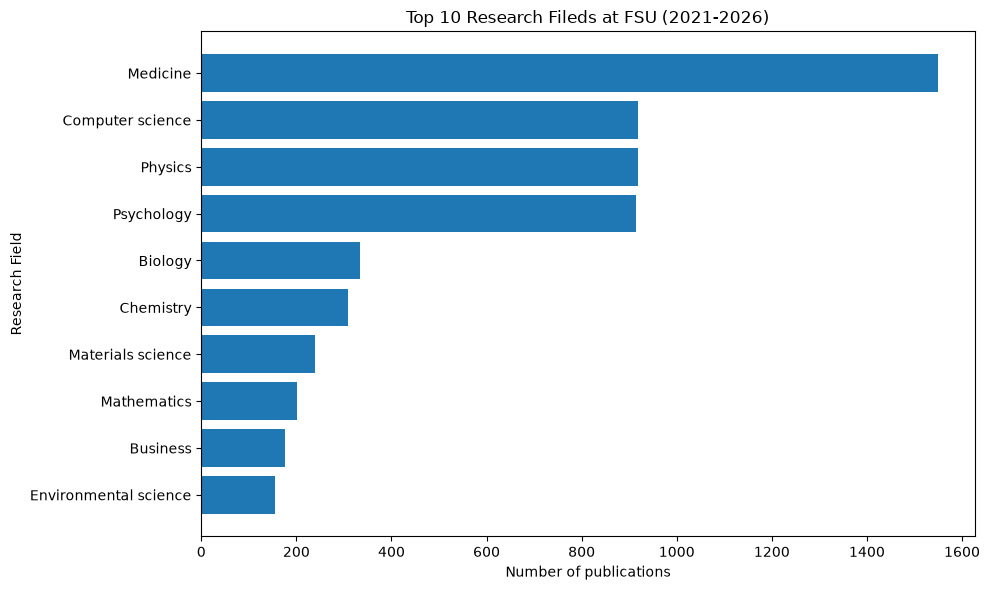

In [41]:
top_10 = (
    df["primary_field"]
    .dropna()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(top_10.index[::-1], top_10.values[::-1])

plt.xlabel("Number of publications")
plt.ylabel("Research Field")
plt.title("Top 10 Research Fileds at FSU (2021-2026)")

plt.tight_layout()
plt.show()

Medicine clearly has the hgihest amount of publications, followed by a nearly tied comp sci, physics, and psych, with it steadily decreasing until the lowest, enviromental science

### Task 4.2: Field × Year Publication Trends

In [44]:
top_5_fields = (
    df["primary_field"]
    .dropna()
    .value_counts()
    .head(5)
    .index
)

print(top_5_fields)

Index(['Medicine', 'Computer science', 'Physics', 'Psychology', 'Biology'], dtype='str', name='primary_field')


In [47]:
field_year_counts = (
    df[df["primary_field"].isin(top_5_fields)]
    .groupby(["publication_year", "primary_field"])
    .size()
    .unstack(fill_value=0)
)

field_year_counts = field_year_counts.reindex(
    columns=top_5_fields
)

print(field_year_counts)



primary_field     Medicine  Computer science  Physics  Psychology  Biology
publication_year                                                          
2021                   150               121      138         135       57
2022                   191               102      146         122       70
2023                   222               119      158         148       48
2024                   262               181      167         161       36
2025                   352               208      149         180       67
2026                   372               188      160         168       56


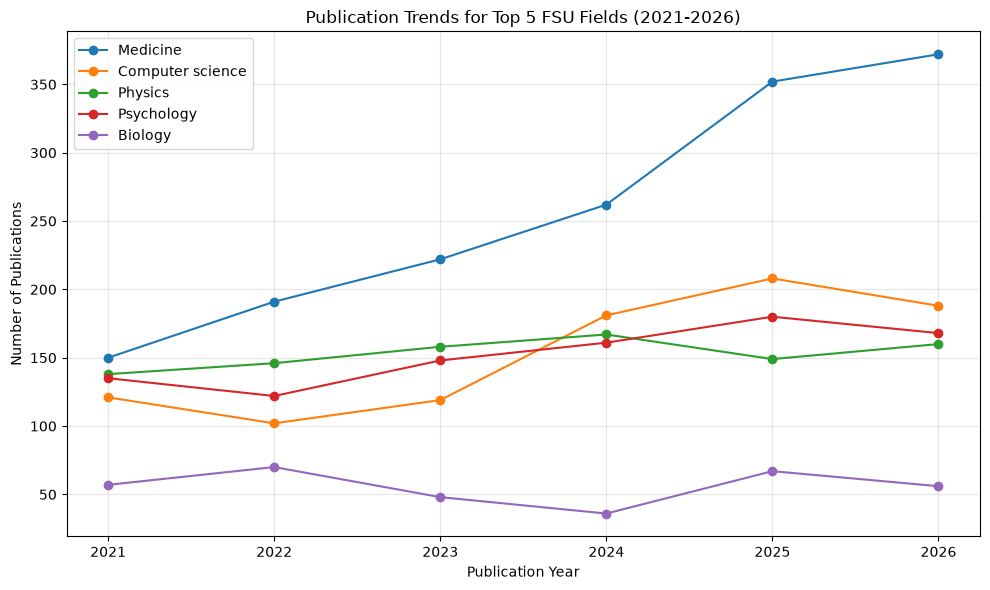

In [48]:
plt.figure(figsize=(10, 6))

for field in top_5_fields:
    plt.plot(
        field_year_counts.index,
        field_year_counts[field],
        marker="o",
        label=field
    )

plt.xlabel("Publication Year")
plt.ylabel("Number of Publications")
plt.title("Publication Trends for Top 5 FSU Fields (2021-2026)")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The lien chart compares publication trends in the five most common research fields at FSU, letting the reader easily see changes in trends within each fields. However, it only compares the top 5 fields, and since 2026 isnt over yet, it shouldnt be interpreted as final annual totals

### Task 4.3: Citation Count Distribution

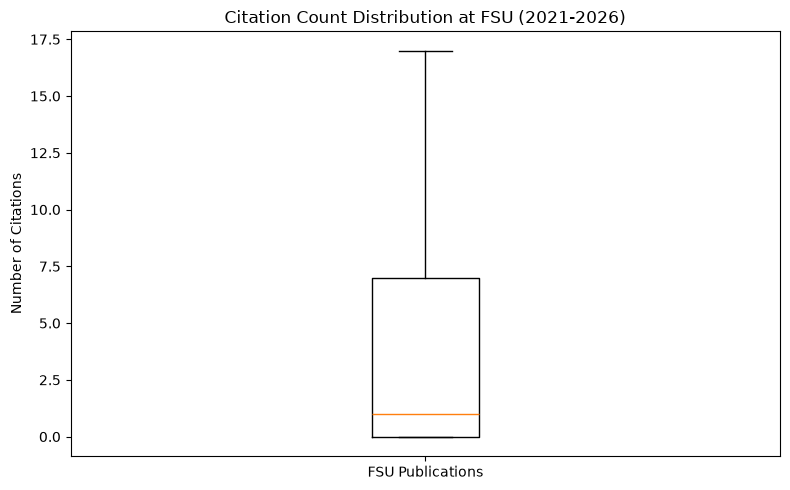

In [51]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    df["cited_by_count"].dropna(),
    showfliers=False
)

plt.ylabel("Number of Citations")
plt.title("Citation Count Distribution at FSU (2021-2026)")
plt.xticks([1], ["FSU Publications"])

plt.tight_layout()
plt.show()

The distribution is strongly skewed with most publications recieving 7 or less, with the median being 1, however, the maximum is very high

## Task 5: Build and Visualize the Citation Network


### Task 5.1: Build the Network

In [3]:
import pandas as pd
import requests
import time
from tqdm.auto import tqdm

df = pd.read_csv("fsu_works_2021_2026.csv")

print("Total FSU works:", len(df))

Total FSU works: 27733


In [4]:
sample_size = 5000
sample_df = df.sample(
    n = sample_size,
    replace = False,
    random_state = 42
)

print("Sample size:", len(sample_df))
sample_df.head()

Sample size: 5000


,openalex_id,doi,title,publication_year,publication_date,type,cited_by_count,venue,venue_id,is_oa,oa_status,authors,n_authors,primary_field,fields_all
6913,https://openalex.org/W4390696040,https://doi.org/10.1177/23337214231224571,Adherence Promotion With Tailored Motivational...,2024,2024-01-01,article,4,Gerontology and Geriatric Medicine,https://openalex.org/S2764736975,True,gold,Shenghao Zhang; Michael Dieciuc; Andrew T. Dil...,8,Psychology,Psychology; Relevance (law); Text message; Mat...
21301,https://openalex.org/W4411505139,https://doi.org/10.1029/2025gb008545,Long‐Term and Seasonal Drivers of Organic Matt...,2025,2025-06-01,article,0,Global Biogeochemical Cycles,https://openalex.org/S32973720,False,closed,Martin R. Kurek; Rafael Corrêa Muniz; José Mau...,7,Dissolved organic carbon,Dissolved organic carbon; Amazon rainforest; T...
15399,https://openalex.org/W4307076411,https://doi.org/10.48550/arxiv.2210.10957,3D Human Mesh Construction Leveraging Wi-Fi,2022,2022-10-20,preprint,1,arXiv (Cornell University),https://openalex.org/S4306400194,True,green,Yichao Wang; Jie Yang,2,Non-line-of-sight propagation,Non-line-of-sight propagation; Computer scienc...
2383,https://openalex.org/W3187100460,https://doi.org/10.3389/fncel.2021.684742,Stimulus Driven Functional Transformations in ...,2021,2021-08-03,article,25,Frontiers in Cellular Neuroscience,https://openalex.org/S36653316,True,gold,Carlotta Martelli; Douglas A. Storace,2,Odor,Odor; Stimulus (psychology); Neuroscience; Sen...
26212,https://openalex.org/W7204908544,https://doi.org/10.5281/zenodo.22237422,SEA STARR output contribution from MIMICA,2026,2026-09-01,dataset,0,Zenodo (CERN European Organization for Nuclear...,https://openalex.org/S4306400562,True,green,Michael Diamond; Alejandro Baró Pérez,2,NaN,NaN


In [6]:
paper_id = sample_df.iloc[0]["openalex_id"]
work_id = paper_id.rsplit("/", 1)[-1]

response = requests.get(
    f"https://api.openalex.org/works/{work_id}",
    params={
        "select": "id,referenced_works,related_works"
    },
    timeout = 60
)

print("Status:", response.status_code)
print(response.text[:1000])

Status: 200
{"id":"https://openalex.org/W4390696040","referenced_works":["https://openalex.org/W1511502075","https://openalex.org/W1539896512","https://openalex.org/W1568955415","https://openalex.org/W1755037248","https://openalex.org/W1771486365","https://openalex.org/W1891875666","https://openalex.org/W1969969444","https://openalex.org/W1986718191","https://openalex.org/W1991313119","https://openalex.org/W2001935231","https://openalex.org/W2013335489","https://openalex.org/W2041779257","https://openalex.org/W2057902960","https://openalex.org/W2086822338","https://openalex.org/W2098901712","https://openalex.org/W2109827187","https://openalex.org/W2162486273","https://openalex.org/W2166930562","https://openalex.org/W2317364698","https://openalex.org/W2340459181","https://openalex.org/W2427775456","https://openalex.org/W2492753408","https://openalex.org/W2528124781","https://openalex.org/W2565825804","https://openalex.org/W2620244105","https://openalex.org/W2739032449","https://openalex

In [7]:
def get_references(paper_id):
    work_id = paper_id.rsplit("/", 1)[-1]

    for attempt in range(3):
        try:
            response = requests.get(
                f"https://api.openalex.org/works/{work_id}",
                params={
                    "select": "id,referenced_works,related_works"
                },
                timeout=60
            )

            response.raise_for_status()
            return response.json()

        except requests.RequestException:
            if attempt == 2:
                raise


            time.sleep(2 * (attempt + 1))

In [8]:
import csv
import os

output_file = "paper_citation_links_all.csv"
progress_file = "citation_crawl_completed.txt"

completed = set()

if os.path.exists(progress_file):
    with open(progress_file, "r", encoding="utf-8") as f:
        completed = set(line.strip() for line in f)

write_header = not os.path.exists(output_file)

with open(output_file, "a", newline = "", encoding="utf-8") as edge_file, \
    open(progress_file, "a", encoding="utf-8") as progress:

    writer = csv.writer(edge_file)

    if write_header:
        writer.writerow(["source", "target"])

    for paper_id in tqdm(
        sample_df["openalex_id"],
        desc="Fetching references"
    ):
        if paper_id in completed:
           continue

        work = get_references(paper_id)

        source = work["id"]

        for target in work.get("referenced_works") or []:
            writer.writerow([source, target])


        edge_file.flush()

        progress.write(paper_id + "\n")
        progress.flush()

        completed.add(paper_id)

        time.sleep(0.1)

print("Completed sampled papers:", len(completed))



Fetching references:   0%|          | 0/5000 [00:00<?, ?it/s]

Completed sampled papers: 5000


In [9]:
all_edges_df = pd.read_csv(
    "paper_citation_links_all.csv"
)

print("Total citation links:", len(all_edges_df))

all_edges_df.head()

Total citation links: 201516


,source,target
0,https://openalex.org/W4390696040,https://openalex.org/W1511502075
1,https://openalex.org/W4390696040,https://openalex.org/W1539896512
2,https://openalex.org/W4390696040,https://openalex.org/W1568955415
3,https://openalex.org/W4390696040,https://openalex.org/W1755037248
4,https://openalex.org/W4390696040,https://openalex.org/W1771486365


In [14]:
fsu_ids = set(df["openalex_id"])

within_fsu_df = all_edges_df[
    all_edges_df["source"].isin(fsu_ids)
    & all_edges_df["target"].isin(fsu_ids)
].copy()

within_fsu_df.to_csv(
    "paper_ciation_links_within_fsu.csv",
    index = False
)

print("All citation links:", len(all_edges_df))
print("FSU-internal links:", len(within_fsu_df))

percentage = (
    len(within_fsu_df) / len(all_edges_df) * 100
    if len(all_edges_df) > 0 else 0
)

print(f"FSU-internal percentage: {percentage:.2f}%")

within_fsu_df.head()

All citation links: 201516
FSU-internal links: 3491
FSU-internal percentage: 1.73%


,source,target
39,https://openalex.org/W4390696040,https://openalex.org/W4221062318
44,https://openalex.org/W4390696040,https://openalex.org/W4320481812
47,https://openalex.org/W4390696040,https://openalex.org/W4366982703
181,https://openalex.org/W4411505139,https://openalex.org/W3136511286
182,https://openalex.org/W4411505139,https://openalex.org/W3169520380


In [15]:
print("All edges columns:", all_edges_df.columns.tolist())
print("Internal edges columns:", within_fsu_df.columns.tolist())

print("All edges:", len(all_edges_df))
print("Internal edges:", len(within_fsu_df))

assert len(within_fsu_df) <= len(all_edges_df)

assert within_fsu_df["source"].isin(fsu_ids).all()
assert within_fsu_df["target"].isin(fsu_ids).all()

print("Verification successful!")

All edges columns: ['source', 'target']
Internal edges columns: ['source', 'target']
All edges: 201516
Internal edges: 3491
Verification successful!


A random sample of 5000 papers was selected, performed without replacement using a fixed random seed of 42 to make the results reproducable. This sample size reduces the number of API rquests, and allows the citation network more managble to visualize. However, it does not capture everyting

### Task 5.2: Static Network Visualization

In [17]:
import networkx as nx
import plotly.graph_objects as go
G = nx.from_pandas_edgelist(
    within_fsu_df,
    source="source",
    target="target",
    create_using=nx.DiGraph()
)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 3762
Edges: 3491


In [18]:
pos = nx.spring_layout(
    G,
    seed = 42
)

In [19]:
edge_x = []
edge_y = []

for source, target in G.edges():
    x0, y0 = pos[source]
    x1, y1 = pos[target]

    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])

edge_trace = go.Scatter(
    x=edge_x,
    y=edge_y,
    mode="lines",
    line=dict(width=0.5, color="gray"),
    hoverinfo="none"
)

In [20]:
node_x = []
node_y = []
node_text = []

for node in G.nodes():
    x, y = pos[node]

    node_x.append(x)
    node_y.append(y)
    node_text.append(node)

node_trace = go.Scatter(
    x=node_x,
    y=node_y,
    mode="markers",
    text=node_text,
    hoverinfo="text",
    marker=dict(
        size=5,
        color="#782F40",
        opacity=0.6
    )
)

In [21]:
fig = go.Figure(
    data=[edge_trace, node_trace]
)

fig.update_layout(
    title="FSU Citation Network (2021-2026)",
    showlegend=False,
    xaxis= dict(
        visible=False,
        showgrid=False,
        zeroline=False
    ),
    yaxis=dict(
        visible=False,
        showgrid=False,
        zeroline=False
    ),
    plot_bgcolor="white",
    hovermode="closest"
)

fig.show()

The citation netwrok represents relationships between FSU affiliated publications, each node represents a paper and each edge represnets a citation. It helps shwo the relationship between groups of publications and citations. The dense regions, however, make it hard to see individual relationships without zooming in. Also, since it is based on only 5000 citing papers, it doesnt represent the full dataset